In [160]:
%load_ext autoreload
%autoreload 2

import numpy as np
from time import time
import matplotlib.pyplot as plt
from main_semi_sticky_wages_data import ModelClass
from plots import plot_shares, plot_series
from helper_functions import params_to_latex

model = ModelClass()

par = model.par
sim = model.sim

par.solver = 'brentq'

model.solve(do_print=True)

params_to_latex(par)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Convergence achieved at iteration 580 with eps = 9.68e-09


The model converges to the steady state:

In [161]:
print(f"Workers supply in high jobs: {[f'{x:.2f}' for x in par.l_h_ss]}")
print(f"Workers supply in low jobs: {[f'{x:.2f}' for x in par.l_l_ss]}")
print(f"Wage of workers in high jobs: {[f'{x:.2f}' for x in par.wage_h_ss]}")
print(f"Wage of workers in low jobs: {[f'{x:.2f}' for x in par.wage_l_ss]}")

Workers supply in high jobs: ['0.09', '0.09', '0.09', '0.09', '0.09', '0.09', '0.09', '0.09', '0.09', '0.09', '0.08', '0.08', '0.08', '0.08', '0.08', '0.08', '0.08', '0.09', '0.09', '0.09', '0.09', '0.08', '0.08', '0.07', '0.06', '0.06', '0.05', '0.05', '0.05', '0.05', '0.04', '0.04', '0.04', '0.04', '0.03', '0.02', '0.02', '0.02', '0.01', '0.01', '0.01', '0.01', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00', '0.00']
Workers supply in low jobs: ['0.91', '0.92', '0.93', '0.90', '0.89', '0.89', '0.87', '0.87', '0.87', '0.88', '0.86', '0.85', '0.85', '0.83', '0.81', '0.83', '0.83', '0.87', '0.92', '0.94', '0.90', '0.84', '0.77', '0.70', '0.62', '0.59', '0.56', '0.54', '0.50', '0.47', '0.45', '0.42', '0.39', '0.36', '0.34', '0.24', '0.19', '0.16', '0.12', '0.10', '0.07', '0.06', '0.03', '0.02', '0.01', '0.00', '0.00', '0.00', '0.00', '0.00']
Wage of workers in high jobs: ['0.18', '0.18', '0.18', '0.19', '0.19', '0.19', '0.19', '0.20', '0.20', '0.20', '0.21', '0.21', '0.22', '0.22'

In [162]:
model.simulate_transition()

array([1.        , 1.00210402, 1.00086969, 1.00623641, 1.00781784,
       1.0081817 , 1.00824304, 1.00646544, 1.00493259, 1.00399236,
       0.99953519, 0.99448379, 0.9899303 , 0.98867909, 0.98680341,
       0.986415  , 0.98267403, 0.97718012, 0.97025242, 0.97290984,
       0.97493663, 0.97541509, 0.9774685 , 0.97909381, 0.98144063,
       0.98420652, 0.986928  , 0.98763725, 0.9874799 , 0.98313633,
       0.98880581, 0.98745925, 0.98599169])

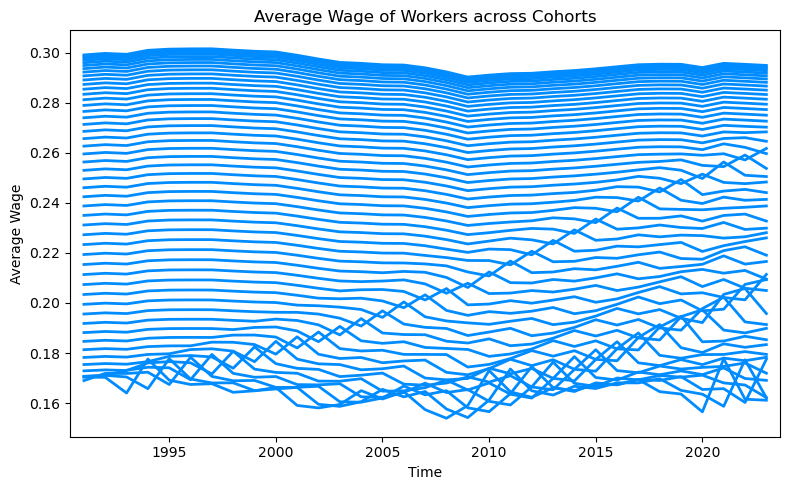

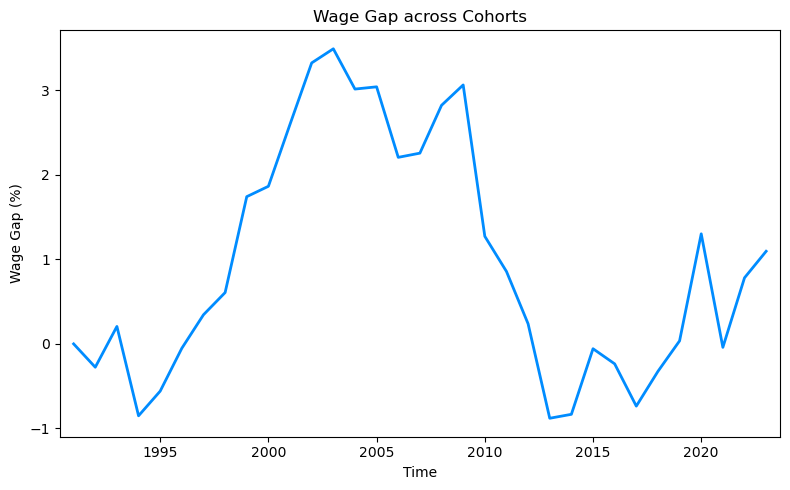

In [186]:
plot_series(model.sim.avg_wage[:, :], title="Average Wage of Workers across Cohorts", ylabel="Average Wage")

wage_gap = (np.average(model.sim.avg_wage[:, -5::]/model.sim.avg_wage[0, -5::], axis=1) - np.average(model.sim.avg_wage[:, :5]/model.sim.avg_wage[0, :5], axis=1))*100
plot_series(wage_gap, title="Wage Gap across Cohorts", ylabel="Wage Gap (%)")